[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [1]:
import os, getpass

def _set_env(var: str):
    # os.environ.pop('ANTHROPIC_API_KEY', None)
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        

_set_env("ANTHROPIC_API_KEY")
_set_env("MODEL_LIST")

ANTHROPIC_API_KEY:  ········
MODEL_LIST:  ········


We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [6]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)
type(result)

OpenAIAuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-ant-a************************************************************************************************HwAA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [4]:
from langchain_anthropic import ChatAnthropic
llm = ChatAnthropic(model="claude-haiku-4-5-20251001",
                    api_key=os.environ['ANTHROPIC_API_KEY'],
                   default_headers={
                    "anthropic-workspace-id": "wrkspc_014M77xdmqSes9xoggBH6Mkf"
        })
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [8]:
result

AIMessage(content="# Best Places to See Orcas in the US\n\nThe top destinations for orca watching in the United States are:\n\n## Pacific Northwest (Best Option)\n- **San Juan Islands, Washington** - This is considered the premier orca watching destination in the US\n  - Located between Washington State and British Columbia\n  - Home to the resident orca population\n  - Best season: June through September\n  - Multiple tour operators available\n\n- **Alaska** - Particularly Southeast Alaska\n  - More remote but excellent viewing opportunities\n  - Best season: May through September\n\n## California\n- **Northern California coast** - Occasional sightings\n- Less reliable than the Pacific Northwest\n\n## Why the San Juan Islands?\n1. **Resident population** - Orcas return to the area predictably\n2. **Accessibility** - Easy to reach from Seattle\n3. **Tour operators** - Many reputable whale watching companies\n4. **Success rates** - High probability of sightings during peak season\n\n## 

In [5]:
result.response_metadata

{'id': 'msg_011Cfm3TDMe6wDGbU3sbqmJj',
 'container': None,
 'model': 'claude-haiku-4-5-20251001',
 'stop_details': None,
 'stop_reason': 'end_turn',
 'stop_sequence': None,
 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0,
   'ephemeral_5m_input_tokens': 0},
  'cache_creation_input_tokens': 0,
  'cache_read_input_tokens': 0,
  'inference_geo': 'not_available',
  'input_tokens': 72,
  'output_tokens': 288,
  'output_tokens_details': None,
  'server_tool_use': None,
  'service_tier': 'standard'},
 'diagnostics': None,
 'model_name': 'claude-haiku-4-5-20251001',
 'model_provider': 'anthropic'}

In [11]:
result.content

"# Best Places to See Orcas in the US\n\nThe top destinations for orca watching in the United States are:\n\n## Pacific Northwest (Best Option)\n- **San Juan Islands, Washington** - This is considered the premier orca watching destination in the US\n  - Located between Washington State and British Columbia\n  - Home to the resident orca population\n  - Best season: June through September\n  - Multiple tour operators available\n\n- **Alaska** - Particularly Southeast Alaska\n  - More remote but excellent viewing opportunities\n  - Best season: May through September\n\n## California\n- **Northern California coast** - Occasional sightings\n- Less reliable than the Pacific Northwest\n\n## Why the San Juan Islands?\n1. **Resident population** - Orcas return to the area predictably\n2. **Accessibility** - Easy to reach from Seattle\n3. **Tour operators** - Many reputable whale watching companies\n4. **Success rates** - High probability of sightings during peak season\n\n## Tips for Orca Watc

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [15]:
from langchain_core.tools import tool

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


@tool
def divide(a: int, b: int) -> float:
    """divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a // b

llm_with_tools = llm.bind_tools([multiply, divide])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [16]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [17]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'toolu_0133RmefnYMrGTNw9ky9HSeb',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [18]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

In [19]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [20]:
from langgraph.graph import MessagesState

class State(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [21]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='00c940c3-2ffd-4316-889c-68906696cee1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='49972f2d-be41-4673-9658-90fa5b6900ad'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='5e8e6574-2e85-470a-aca9-a0dd2f5961f6', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

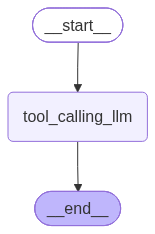

In [22]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [23]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! 👋 I'm here to help you with some basic math operations. I can:

- **Multiply** two numbers together
- **Divide** one number by another

Feel free to ask me to perform any calculations you need! For example, you could ask me to multiply 5 and 3, or divide 20 by 4. What would you like to calculate?


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [24]:
messages = graph.invoke({"messages": HumanMessage(content="divide 6 and 2")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

divide 6 and 2
================================== Ai Message ==================================

[{'id': 'toolu_01TpLJ6CBnYPBLWtxfFF431N', 'caller': {'type': 'direct'}, 'input': {'a': 6, 'b': 2}, 'name': 'divide', 'type': 'tool_use', 'toolset_name': None}]
Tool Calls:
  divide (toolu_01TpLJ6CBnYPBLWtxfFF431N)
 Call ID: toolu_01TpLJ6CBnYPBLWtxfFF431N
  Args:
    a: 6
    b: 2


In [42]:
import os
import json
from typing import Annotated
from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolArg
from langchain_anthropic import ChatAnthropic
# from langchain_anthropic import ChatAnthropic
from langgraph.prebuilt import create_react_agent

# Make sure your API key is set
# os.environ["ANTHROPIC_API_KEY"] = "your-api-key"

# ----------------------------------------------------
# 1. DEFINE THE TOOL WITH RUNTIME CONFIG
# ----------------------------------------------------
@tool
def get_user_balance(
    account_type: str,
    # This annotation hides 'user_id' from the LLM schema completely!
    user_id: Annotated[str, InjectedToolArg] 
) -> str:
    """Retrieve the balance for a specific account type.
    
    Args:
        account_type: The type of account, e.g., 'checking' or 'savings'.
    """
    # In a real app, you would query a database using the injected user_id
    if user_id == "usr_12345" and account_type == "checking":
        return "$1,500.00"
    return "$0.00"


# ----------------------------------------------------
# 2. SETUP THE MODEL AND THE LANGGRAPH AGENT
# ----------------------------------------------------
modelList = json.loads(os.environ["MODEL_LIST"])
##print(modelList[3])
model = ChatAnthropic(model=modelList[3], temperature=0)

# Build the tools list
tools = [get_user_balance]

# create_react_agent automatically binds tools to the model 
# and handles the execution loop natively
agent_executor = create_react_agent(model, tools)


# ----------------------------------------------------
# 3. RUN THE AGENT WITH CONFIGURATION
# ----------------------------------------------------
# The LLM prompt ONLY mentions checking balance; it doesn't know the user_id
inputs = {"messages": [("user", "How much money do I have in my checking account?")]}

# We pass the runtime configuration inside the 'config' dictionary
config = {
    "configurable": {
        "user_id": "usr_12345" # This is automatically matched to the InjectedToolArg
    }
}

# Run the graph loop
for chunk in agent_executor.stream(inputs, config=config):
     for node_name, node_output in chunk.items():
        if "messages" in node_output:
            for message in node_output["messages"]:
                # Print the role/type of message and its content
                print(f"--- Message from Node [{node_name}] ---")
                print(f"Role: {message.type}")
                print(f"Content: {message.content}\n")


C:\Users\nayek\AppData\Local\Temp\ipykernel_20016\3631371130.py:45: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(model, tools)


--- Message from Node [agent] ---
Role: ai
Content: [{'id': 'toolu_01EFMFiHaAsyfB55qajDfWer', 'caller': {'type': 'direct'}, 'input': {'account_type': 'checking'}, 'name': 'get_user_balance', 'type': 'tool_use', 'toolset_name': None}]

--- Message from Node [tools] ---
Role: tool
Content: Error invoking tool 'get_user_balance' with kwargs {'account_type': 'checking'} with error:
 user_id: Field required
 Please fix the error and try again.

--- Message from Node [agent] ---
Role: ai
Content: I apologize, but I'm unable to retrieve your checking account balance at the moment. The system requires additional authentication information (a user ID) that I don't have access to. 

To check your checking account balance, you may want to:
- Log into your bank's website or mobile app directly
- Call your bank's customer service line
- Visit a branch in person

Is there anything else I can help you with?

